gabriel

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import contextily as cx
import numpy as np

In [3]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False)
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

df = df_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Phalacrocorax carbo        str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


In [5]:
print(df_sightings["Phalacrocorax carbo"].unique())

<StringArray>
[      '0',       '1',       '2',       '4',       '3',       '5',       '6',
       '7',      '10',      '11',      '20',       '9',       '8',      '15',
      '17',      '16',      '12',      '14',      '24',      '22',      '25',
      '21',      '27',      '18',      '50',      '13',      '28',      '26',
      '35',      '23',      '19',      '43',      '56',      '36',      '30',
      '41',      '62',      '32',      '37',      '34',      '31',      '51',
      '67',      '29',      '42',      '55',     '109',      '45',      '57',
      '58',      '38',      '33',      '63',      '-1', 'unknown']
Length: 55, dtype: str


In [6]:
df.to_csv('bird_and_habitats.csv', index=False)

In [7]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 20 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  year                       int32         
 16  month                      int32         
 17

In [9]:
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month
df['week'] = df['eventDate'].dt.isocalendar().week

In [10]:
df.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,year,month,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,2010,1,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,2010,1,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,2010,1,53
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,2010,1,1
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,2010,1,1


In [11]:
df.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,year,month,week
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast,2025,12,52
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast,2025,12,52
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast,2025,12,1
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast,2025,12,1
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast,2025,12,1


In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
decimalLatitude,12558756.0,52.23006,50.75,51.7,52.2,52.8,53.5,0.660521
decimalLongitude,12558756.0,5.532783,3.35,4.9,5.65,6.2,7.2,0.874886
eventDate,12558756,2017-12-31 11:59:59.999999,2010-01-01 00:00:00,2013-12-31 18:00:00,2017-12-31 12:00:00,2021-12-31 06:00:00,2025-12-31 00:00:00,NaN
total_observations,12558756.0,8.067763,0.0,0.0,1.0,6.0,100040.0,39.125017
speciesgroup_observations,12558756.0,4.330658,0.0,0.0,0.0,2.0,2779.0,16.067937
Phalacrocorax carbo,12558756.0,0.051434,0.0,0.0,0.0,0.0,109.0,0.336498
agricultural,12558756.0,9.452277,0.0,5.3484,10.5682,13.8008,18.1046,5.147907
built,12558756.0,2.404833,0.0,0.7667,1.5599,3.2916,14.3538,2.419758
coast,12558756.0,1.302932,0.0,0.0,0.0,0.0,19.3487,3.970215
forest,12558756.0,1.621184,0.0,0.1494,0.7092,2.0364,16.9985,2.385737


In [13]:
print(df[(df['Phalacrocorax carbo'] > 5) & (df['wetland'] == 0)]['main_habitat'].value_counts())

main_habitat
coast           655
built           154
agricultural    138
water            70
other            11
forest            2
Name: count, dtype: int64


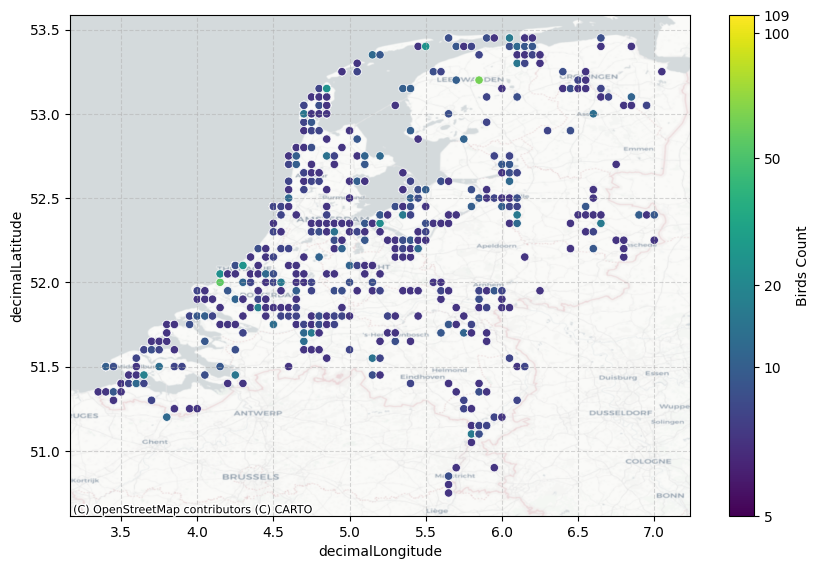

In [14]:
dfX = df[(df['Phalacrocorax carbo'] > 5) & (df['year'] >= 2020) & (df['year'] <= 2025) ]
my_norm = colors.PowerNorm(gamma=0.4, vmin=5, vmax=109)

plt.figure(figsize=(10, 6.5))
# 1. Plot (notice legend=False)
ax = sns.scatterplot(
    data=dfX, x='decimalLongitude', y='decimalLatitude', 
    hue='Phalacrocorax carbo', hue_norm=my_norm, palette='viridis', legend=False
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
# 2. Add a colorbar and force your exact numbers onto it
sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = plt.colorbar(sm, ax=ax, label='Birds Count')
cbar.set_ticks([5, 10, 20, 50, 100, 109])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

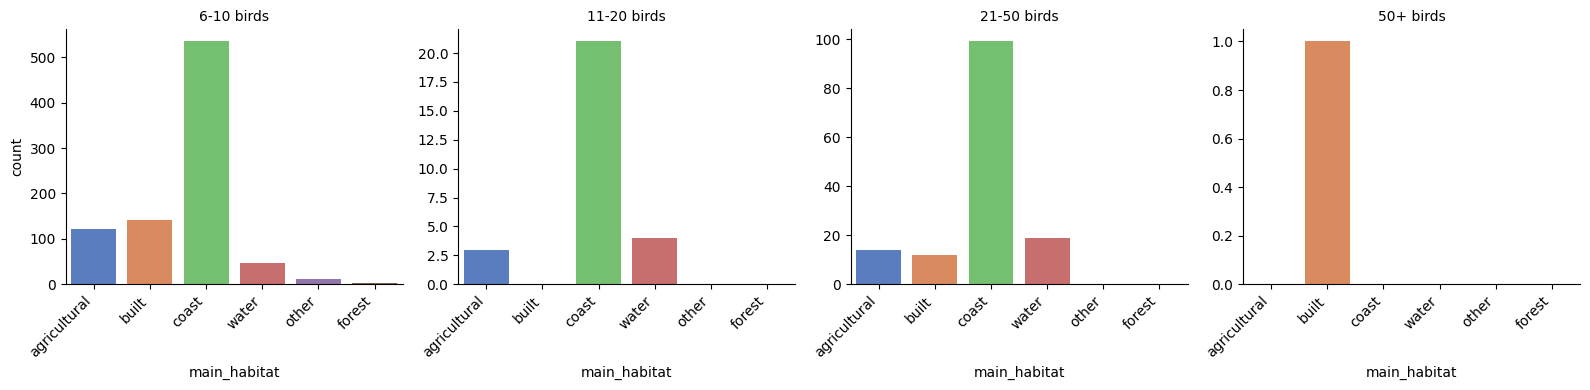

In [15]:
# 1. Filter out wetlands and bucket the counts
df_non_wetland = df[df['wetland'] == 0].copy()
df_non_wetland['bird_brackets'] = pd.cut(
    df_non_wetland['Phalacrocorax carbo'], 
    bins=[5, 10, 20, 50, float('inf')], 
    labels=['6-10 birds', '11-20 birds', '21-50 birds', '50+ birds']
)
df_filtered = df_non_wetland.dropna(subset=['bird_brackets'])

# 2. Use catplot to split into separate subplots side-by-side
g = sns.catplot(
    data=df_filtered,
    x='main_habitat',
    hue='main_habitat',
    col='bird_brackets',    # Creates a separate plot for each bracket
    kind='count',
    sharey=False,           # CRITICAL: Gives each plot its own Y-axis scale!
    palette='muted',
    height=4,
    aspect=1.0
)

# Rotate habitat labels so they don't overlap
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("{col_name}") # Cleans up the subplot titles

plt.tight_layout()
plt.show()

/tmp/ipykernel_16064/368129399.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


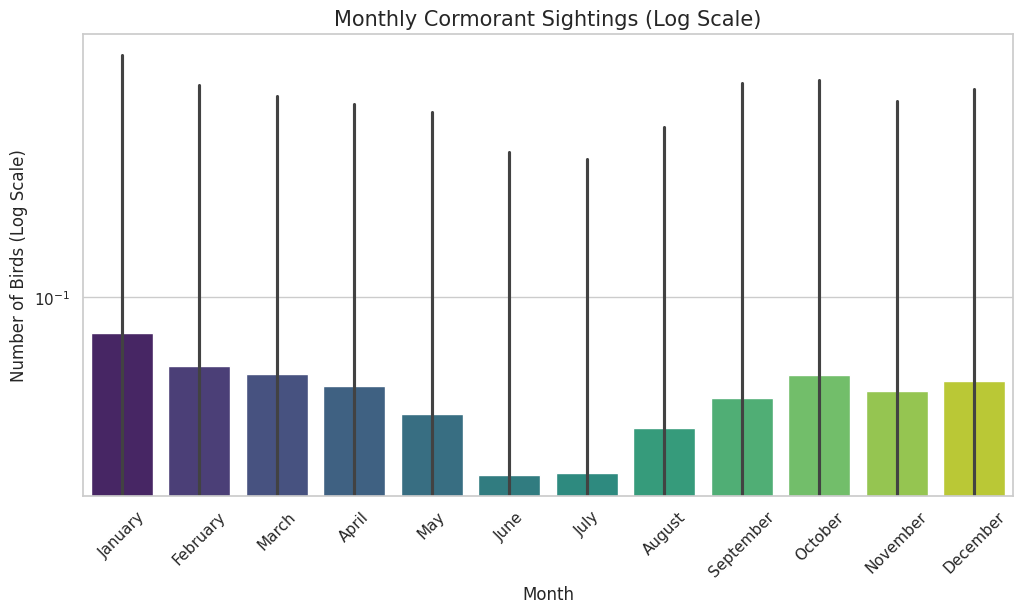

In [16]:
import numpy as np

# 1. Ensure numeric and handle zeros
# We add a tiny amount (1) to the count if we want to include zero-sighting records 
# in a log plot, otherwise log(0) causes errors.
# 1. Re-create the time features from the eventDate string
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['month_num'] = df['eventDate'].dt.month
df['month_name'] = df['eventDate'].dt.month_name()

# 2. Setup the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Sort by month_num so it goes Jan -> Dec, not alphabetical
df_sorted = df.sort_values('month_num')

# 4. The Bar Chart
ax = sns.barplot(
    data=df_sorted, 
    x='month_name', 
    y='Phalacrocorax carbo',
    palette='viridis',
    errorbar='sd' # Standard deviation is better for this noisy data
)

# 5. Apply the Log Scale (essential for bird counts)
# We use a small offset (e.g., 0.1) if there are zeros to avoid math errors
ax.set_yscale("log")

# 6. Labels and Formatting
plt.title('Monthly Cormorant Sightings (Log Scale)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Birds (Log Scale)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

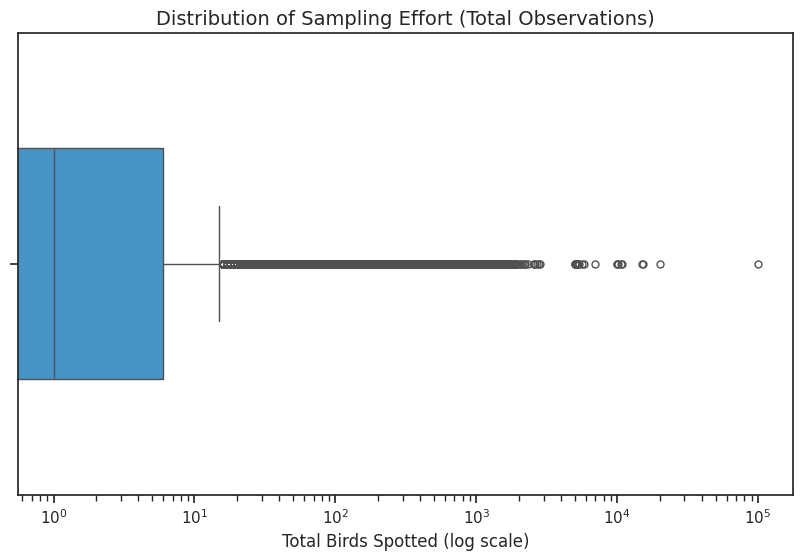

In [17]:
# 1. Setup the figure
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

# 2. Create the Boxplot
# We'll plot it vertically to see the distribution of effort
ax = sns.boxplot(
    x=df['total_observations'], 
    color='#3498db',
    width=0.5,
    fliersize=5  # Size of the outlier dots
)

# 3. Add a log scale (Highly recommended for 'total_observations')
# Sampling effort usually ranges from 1 to 10,000; without log, 
# the 'box' will look like a flat line at the bottom.
ax.set_xscale("log")

# 4. Labels
plt.title('Distribution of Sampling Effort (Total Observations)', fontsize=14)
plt.xlabel('Total Birds Spotted (log scale)', fontsize=12)

plt.show()

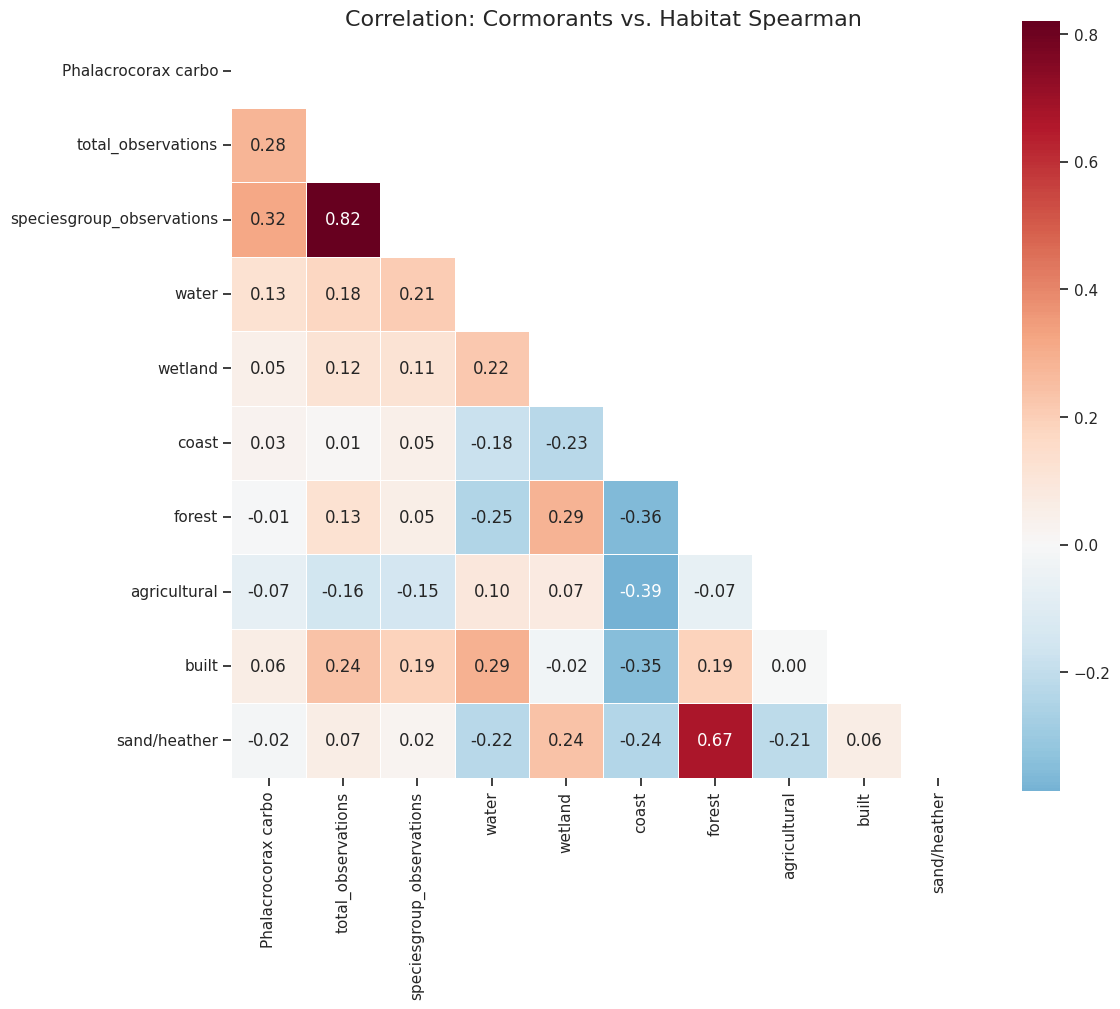

In [18]:
# 1. Select the target and the new habitat features
habitat_cols = [
    'Phalacrocorax carbo', 'total_observations', 'speciesgroup_observations', 'water', 'wetland', 
    'coast', 'forest', 'agricultural', 'built', 'sand/heather'
]

# Calculate correlation
corr_matrix = df[habitat_cols].corr(method="spearman")

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Spearman', fontsize=16)
plt.show()

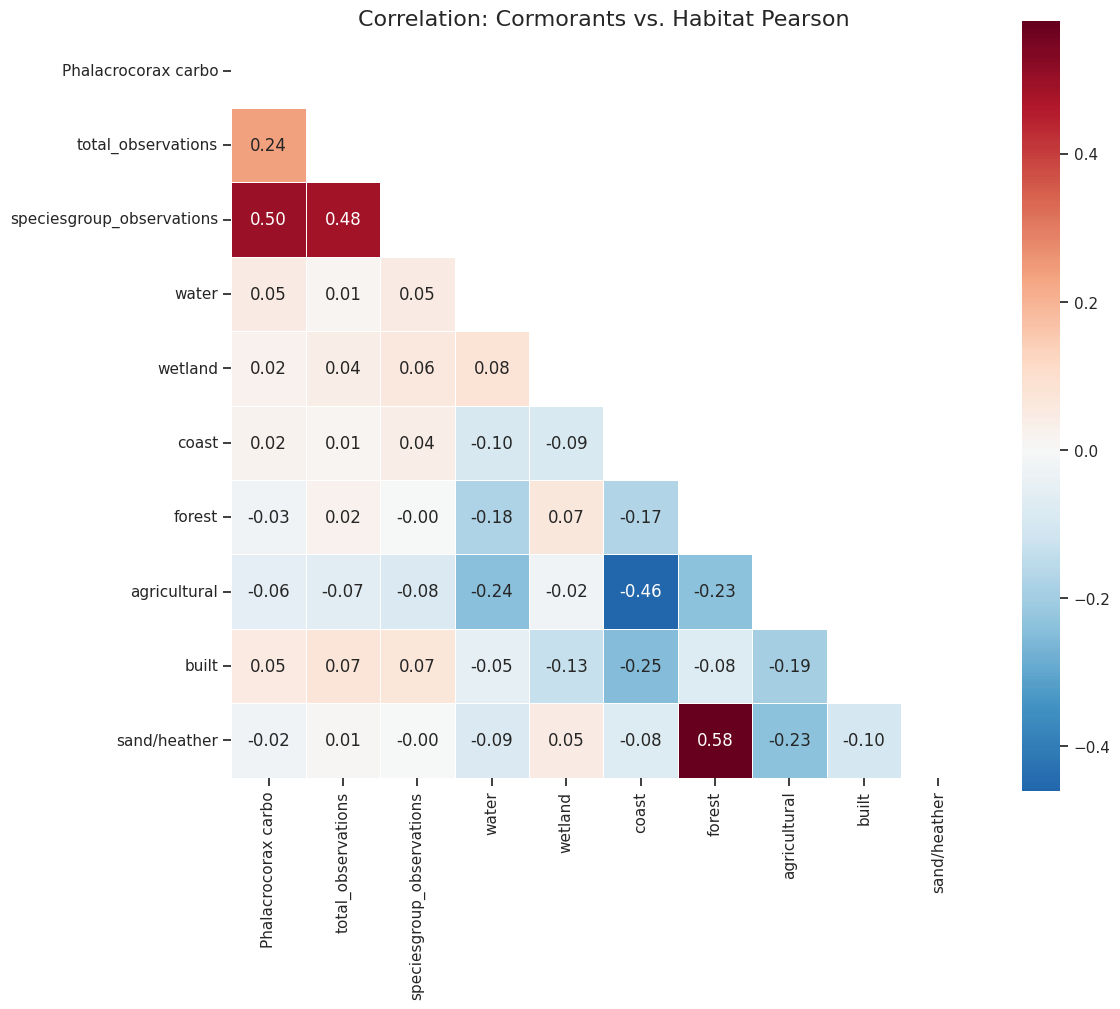

In [19]:
corr_matrix = df[habitat_cols].corr()

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Pearson', fontsize=16)
plt.show()